# 🛒 Online Retail Sales Analysis

## Project Overview

This project analyzes online retail transaction data to identify sales trends, top-performing products, valuable customers, and key market insights.

The analysis covers:
- Data Cleaning
- Sales Analysis
- Product Analysis
- Customer Analysis
- Country Analysis
- Time Analysis
- Statistical Analysis with NumPy
- Data Visualization with Matplotlib
- Business Insights

## 1. Import Libraries & Load Data

In this section, we import the required Python libraries and load the Online Retail dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("data/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Initial Data Exploration

Before cleaning the dataset, we inspect its structure, data types, summary statistics, and missing values.

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("____________________________________________________________________________________________________________________")
print(df.info())
print("____________________________________________________________________________________________________________________")
print(df.describe())
print("____________________________________________________________________________________________________________________")
print(df.isnull().sum())

Dataset Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
____________________________________________________________________________________________________________________
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None
_____________________________________________

### Initial Observations

The dataset contains transaction-level retail data including invoices, products, quantities, prices, customers, dates, and countries.

The initial inspection reveals missing values in `Description` and `CustomerID`, as well as unusual values in `Quantity` and `UnitPrice`.

## 3. Data Cleaning

The raw dataset contains cancellations, invalid quantities, zero prices, missing customer IDs, and duplicate transactions.

The cleaning process focuses on preparing a reliable dataset for sales analysis while preserving useful information whenever possible.

### 3.1 Identifying Cancelled Transactions

Invoices starting with `C` are treated as cancelled transactions.

In [5]:
cancelled_transactions = df[df['InvoiceNo'].astype(str).str.startswith('C')]

print("Cancelled Transactions:", len(cancelled_transactions))
cancelled_transactions['Quantity'].describe()

Cancelled Transactions: 9288


count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

### 3.2 Removing Cancelled Transactions

Cancelled transactions are excluded from the sales dataset because they do not represent completed sales.

In [6]:
sales_df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()

### 3.3 Removing Invalid Sales Records

Transactions with non-positive quantities or non-positive unit prices are excluded from the sales analysis.

In [7]:
sales_df = sales_df[(sales_df['Quantity'] > 0) & (sales_df['UnitPrice'] > 0)].copy()

### 3.4 Creating Revenue

Revenue is calculated as:
`Revenue = Quantity × UnitPrice`

In [8]:
sales_df['Revenue'] = (sales_df['Quantity'] * sales_df['UnitPrice'])

### 3.5 Removing Exact Duplicates

Exact duplicate transaction rows are removed to avoid counting the same record multiple times.

In [9]:
duplicates = sales_df.duplicated().sum()
print("Exact Duplicates:", duplicates)

sales_df = sales_df.drop_duplicates().copy()
print("Shape after removing duplicates:", sales_df.shape)


Exact Duplicates: 5226
Shape after removing duplicates: (524878, 9)


## 4. Feature Engineering

New time-based features are extracted from `InvoiceDate` to support temporal analysis.

In [10]:
sales_df['Year'] = sales_df['InvoiceDate'].dt.year
sales_df['Month'] = sales_df['InvoiceDate'].dt.month
sales_df['MonthName'] = sales_df['InvoiceDate'].dt.month_name()
sales_df['DayOfWeek'] = sales_df['InvoiceDate'].dt.day_name()
sales_df['Hour'] = sales_df['InvoiceDate'].dt.hour

sales_df[['InvoiceDate','Year','Month','MonthName','DayOfWeek','Hour']].head()

,InvoiceDate,Year,Month,MonthName,DayOfWeek,Hour
0,2010-12-01 08:26:00,2010,12,December,Wednesday,8
1,2010-12-01 08:26:00,2010,12,December,Wednesday,8
2,2010-12-01 08:26:00,2010,12,December,Wednesday,8
3,2010-12-01 08:26:00,2010,12,December,Wednesday,8
4,2010-12-01 08:26:00,2010,12,December,Wednesday,8


## 5. Sales Analysis

This section evaluates the overall sales performance using key business metrics.

In [11]:
total_revenue = sales_df['Revenue'].sum()
total_quantity = sales_df['Quantity'].sum()
total_orders = sales_df['InvoiceNo'].nunique()
total_products = sales_df['StockCode'].nunique()
total_customers = sales_df['CustomerID'].nunique()

order_revenue = sales_df.groupby('InvoiceNo')['Revenue'].sum()
average_order_value = order_revenue.mean()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £10,642,110.80
Total Quantity Sold: 5,572,420
Total Orders: 19,960
Total Products: 3,922
Total Customers: 4,338
Average Order Value: £533.17


### 5.1 Monthly Sales Performance

In [12]:
monthly_sales=sales_df.groupby(["Year","Month","MonthName"]).agg(revenue=('Revenue','sum'),Quantity=('Quantity','sum'),Orders=('InvoiceNo','nunique')).reset_index()
monthly_sales

,Year,Month,MonthName,revenue,Quantity,Orders
0,2010,12,December,821452.730,358019,1559
1,2011,1,January,689811.610,387099,1086
2,2011,2,February,522545.560,282934,1100
3,2011,3,March,716215.260,376599,1454
4,2011,4,April,536968.491,307953,1246
5,2011,5,May,769296.610,395001,1681
6,2011,6,June,760547.010,388511,1533
7,2011,7,July,718076.121,399693,1475
8,2011,8,August,757841.380,421020,1361
9,2011,9,September,1056435.192,569573,1837


### 5.2 Average Order Value by Month

In [13]:
monthly_aov=(sales_df.groupby(['Year','Month','MonthName','InvoiceNo'])['Revenue'].sum().groupby(['Year','Month','MonthName']).mean().reset_index(name='average_order_value'))
monthly_aov

,Year,Month,MonthName,average_order_value
0,2010,12,December,526.910026
1,2011,1,January,635.185645
2,2011,2,February,475.041418
3,2011,3,March,492.582710
4,2011,4,April,430.953845
5,2011,5,May,457.642243
6,2011,6,June,496.116771
7,2011,7,July,486.831268
8,2011,8,August,556.826877
9,2011,9,September,575.087203


## 6. Product Analysis

This section identifies the products that generate the highest revenue and sales volume.

### 6.1 Product Revenue Analysis

In [14]:
sales_df_clean = sales_df[sales_df['Quantity'] <= 5000].copy()

product_sales = sales_df_clean[~sales_df_clean['StockCode'].isin(['DOT', 'POST', 'M'])].copy()

top_products = (product_sales.groupby(['StockCode', 'Description']).agg(TotalQuantity=('Quantity', 'sum'),TotalRevenue=('Revenue', 'sum')).sort_values('TotalRevenue', ascending=False).head(10).reset_index())
top_products['AverageUnitPrice'] = (top_products['TotalRevenue'] / top_products['TotalQuantity'])
top_products

,StockCode,Description,TotalQuantity,TotalRevenue,AverageUnitPrice
0,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,12.573572
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2.774993
2,47566,PARTY BUNTING,18283,99445.23,5.439218
3,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,1.946617
4,23084,RABBIT NIGHT LIGHT,30739,66870.03,2.175413
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,3.356386
6,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1.620582
7,79321,CHILLI LIGHTS,10302,54096.36,5.251054
8,23298,SPOTTY BUNTING,8320,42513.48,5.109793
9,22386,JUMBO BAG PINK POLKADOT,21448,42401.01,1.976921


### 6.2 Top Products by Quantity

In [15]:
top_products_quantity=(product_sales.groupby(['StockCode','Description']).agg(TotalQuantity=('Quantity','sum'),TotalRevenue=('Revenue','sum')).sort_values('TotalQuantity',ascending=False).head(10).reset_index())
top_products_quantity

,StockCode,Description,TotalQuantity,TotalRevenue
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01
1,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24
3,22197,POPCORN HOLDER,36749,34288.67
4,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45
5,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62
6,23084,RABBIT NIGHT LIGHT,30739,66870.03
7,22492,MINI PAINT SET VINTAGE,26633,16937.82
8,22616,PACK OF 12 LONDON TISSUES,26119,7975.98
9,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24820,12226.32


### 6.3 Low-Performing Products

In [16]:
low_quantity_products=(product_sales.groupby(['StockCode','Description']).agg(TotalQuantity=('Quantity','sum'),TotalRevenue=('Revenue','sum')).query('TotalQuantity <= 5').sort_values('TotalQuantity',ascending=True).head(30).reset_index())

low_Revenue_products=(product_sales.groupby(['StockCode','Description']).agg(TotalQuantity=('Quantity','sum'),TotalRevenue=('Revenue','sum')).query('TotalQuantity <= 5').sort_values('TotalRevenue',ascending=True).head(30).reset_index())

low_performing_products = (product_sales.groupby(['StockCode', 'Description']).agg(TotalQuantity=('Quantity', 'sum'),TotalRevenue=('Revenue', 'sum')).query('TotalQuantity <= 5 and TotalRevenue < 5').sort_values(['TotalQuantity', 'TotalRevenue']).reset_index())
low_performing_products.head(20)

,StockCode,Description,TotalQuantity,TotalRevenue
0,84227,HEN HOUSE W CHICK IN NEST,1,0.42
1,23366,SET 12 COLOURING PENCILS DOILEY,1,0.65
2,51014c,"FEATHER PEN,COAL BLACK",1,0.83
3,90084,PINK CRYSTAL GUITAR PHONE CHARM,1,0.85
4,21009,ETCHED GLASS STAR TREE DECORATION,1,1.25
5,23370,SET 36 COLOURING PENCILS DOILEY,1,1.25
6,37461,FUNKY MONKEY MUG,1,1.25
7,84977,WIRE FLOWER T-LIGHT HOLDER,1,1.25
8,35597A,DUSTY PINK CHRISTMAS TREE 30CM,1,1.25
9,35597B,BLACKCHRISTMAS TREE 30CM,1,1.25


## 7. Customer Analysis

Customer-level analysis focuses on revenue, order frequency, and average order value to identify high-value and loyal customers.

In [17]:
customer_sales=sales_df_clean.dropna(subset=["CustomerID"]).copy()

print("Rows:", len(customer_sales))
print("Unique Customers:", customer_sales['CustomerID'].nunique())

Rows: 392690
Unique Customers: 4337


In [18]:
customer_revenue=(customer_sales.groupby('CustomerID').agg(TotalRevenue=('Revenue','sum'),TotalQuantity=('Quantity','sum'),TotalOrders=('InvoiceNo','nunique')).sort_values('TotalRevenue',ascending=False).reset_index())
customer_revenue['AverageOrderValue'] = (customer_revenue['TotalRevenue'] /customer_revenue['TotalOrders'])
customer_revenue.head(10)

,CustomerID,TotalRevenue,TotalQuantity,TotalOrders,AverageOrderValue
0,14646.0,280206.02,196915,73,3838.438630
1,18102.0,259657.30,64124,60,4327.621667
2,17450.0,194390.79,69973,46,4225.886739
3,14911.0,143711.17,80240,201,714.980945
4,12415.0,124914.53,77374,21,5948.310952
5,14156.0,117210.08,57768,55,2131.092364
6,17511.0,91062.38,64549,31,2937.496129
7,16029.0,80850.84,40108,63,1283.346667
8,16684.0,66653.56,50255,28,2380.484286
9,14096.0,65164.79,16352,17,3833.222941


### 7.2 Most Loyal Customers

In [19]:
loyal_customers=(customer_revenue.sort_values('TotalOrders', ascending=False).head(10))
loyal_customers

,CustomerID,TotalRevenue,TotalQuantity,TotalOrders,AverageOrderValue
26,12748.0,33053.19,25287,209,158.149234
3,14911.0,143711.17,80240,201,714.980945
20,17841.0,40519.84,22834,124,326.772903
12,13089.0,58762.08,31025,97,605.794639
78,14606.0,12076.15,6187,93,129.851075
11,15311.0,60632.75,38147,91,666.293956
83,12971.0,11189.91,9289,86,130.115233
0,14646.0,280206.02,196915,73,3838.438630
7,16029.0,80850.84,40108,63,1283.346667
32,13408.0,28117.04,16232,62,453.500645


## 8. Country Analysis

This section compares markets based on revenue, number of customers, orders, and average order value.

### 8.1 Customers by Country

In [20]:
country_customer=(customer_sales.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False))
country_customer.head(10)

Country
United Kingdom    3919
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

### 8.2 Revenue by Country

In [21]:
country_revenue=(customer_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False))
country_revenue.head(10)

Country
United Kingdom    7039371.444
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

### 8.3 Average Order Value by Country

In [22]:
country_aov=(customer_sales.groupby('Country').agg(TotalRevenue=('Revenue', 'sum'),TotalOrders=('InvoiceNo', 'nunique')))
country_aov['AOV']=(country_aov['TotalRevenue'] / country_aov['TotalOrders'])
country_aov = country_aov.sort_values('AOV',ascending=False)
country_aov.head(10)

,TotalRevenue,TotalOrders,AOV
Country,,,
Singapore,21279.29,7,3039.898571
Netherlands,285446.34,94,3036.663191
Australia,138453.81,57,2429.014211
Japan,37416.37,19,1969.282632
Lebanon,1693.88,1,1693.880000
Israel,7215.84,5,1443.168000
Brazil,1143.60,1,1143.600000
Switzerland,56443.95,51,1106.744118
Sweden,38367.83,36,1065.773056


## 9. Time Analysis

Time-based analysis is used to identify the days and hours with the highest sales activity.

### 9.1 Revenue by Day of Week

In [23]:
weekday_sales = (sales_df_clean.groupby('DayOfWeek')['Revenue'].sum().sort_values(ascending=False))
weekday_sales

DayOfWeek
Thursday     2199292.570
Tuesday      2098516.911
Wednesday    1847074.380
Monday       1775782.071
Friday       1669000.891
Sunday        806790.781
Name: Revenue, dtype: float64

### 9.2 Revenue by Hour

In [24]:
hourly_sales = (sales_df_clean.groupby('Hour')['Revenue'].sum().sort_values(ascending=False))
hourly_sales

Hour
12    1439324.660
10    1367631.171
15    1350333.310
13    1261195.200
11    1236573.290
14    1177907.521
9      821585.391
16     752487.960
17     460963.921
8      283750.680
18     144603.610
19      50204.950
7       31059.210
20      18832.480
6           4.250
Name: Revenue, dtype: float64

## 10. Statistical Analysis with NumPy

NumPy is used to calculate statistical measures and investigate the distribution of sales data.

### 10.1 Revenue Statistics

In [25]:
revenue = sales_df_clean['Revenue'].to_numpy()
print("Mean:", np.mean(revenue))
print("Median:", np.median(revenue))
print("Standard Deviation:", np.std(revenue))
print("Minimum:", np.min(revenue))
print("Maximum:", np.max(revenue))

Mean: 19.80745472073404
Median: 9.92
Standard Deviation: 91.72035038329408
Minimum: 0.001
Maximum: 38970.0


### 10.2 Revenue Percentiles

In [26]:
print("90th Percentile:", np.percentile(revenue, 90))
print("95th Percentile:", np.percentile(revenue, 95))
print("99th Percentile:", np.percentile(revenue, 99))


90th Percentile: 33.0
95th Percentile: 59.8
99th Percentile: 183.60000000000002


### 10.3 Revenue Outlier Analysis

In [27]:
q1 = np.percentile(revenue, 25)
q3 = np.percentile(revenue, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.9
Q3: 17.700000000000003
IQR: 13.800000000000002
Lower Bound: -16.800000000000004
Upper Bound: 38.400000000000006


### 10.4 Customer Revenue Distribution

In [28]:
customer_values = customer_revenue['TotalRevenue'].to_numpy()
print("Mean:", np.mean(customer_values))
print("Median:", np.median(customer_values))
print("90th Percentile:", np.percentile(customer_values, 90))
print("95th Percentile:", np.percentile(customer_values, 95))

Mean: 1992.5191823841365
Median: 668.4300000000001
90th Percentile: 3638.77
95th Percentile: 5742.945999999997


### 10.5 Quantity Statistics

In [29]:
quantity = sales_df_clean['Quantity'].to_numpy()
print("Mean:", np.mean(quantity))
print("Median:", np.median(quantity))
print("Standard Deviation:", np.std(quantity))
print("90th Percentile:", np.percentile(quantity, 90))
print("99th Percentile:", np.percentile(quantity, 99))

Mean: 10.320932944162049
Median: 4.0
Standard Deviation: 37.914128802805415
90th Percentile: 24.0
99th Percentile: 100.0


## 11. Data Visualization

Matplotlib is used to visualize the main patterns discovered during the analysis.

### 11.1 Monthly Revenue Trend

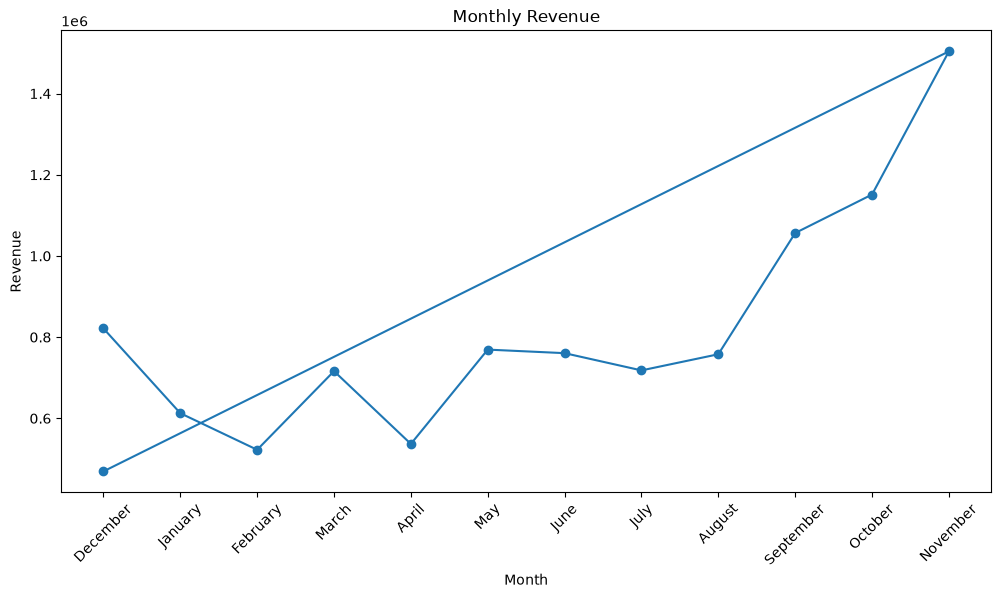

In [30]:
monthly_sales = (sales_df_clean.groupby(['Year', 'Month', 'MonthName']).agg(Revenue=('Revenue', 'sum'),Quantity=('Quantity', 'sum'),Orders=('InvoiceNo', 'nunique')).reset_index())

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['MonthName'],monthly_sales['Revenue'],marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

### 11.2 Top 10 Products by Revenue

Text(0, 0.5, 'Total Revenue')

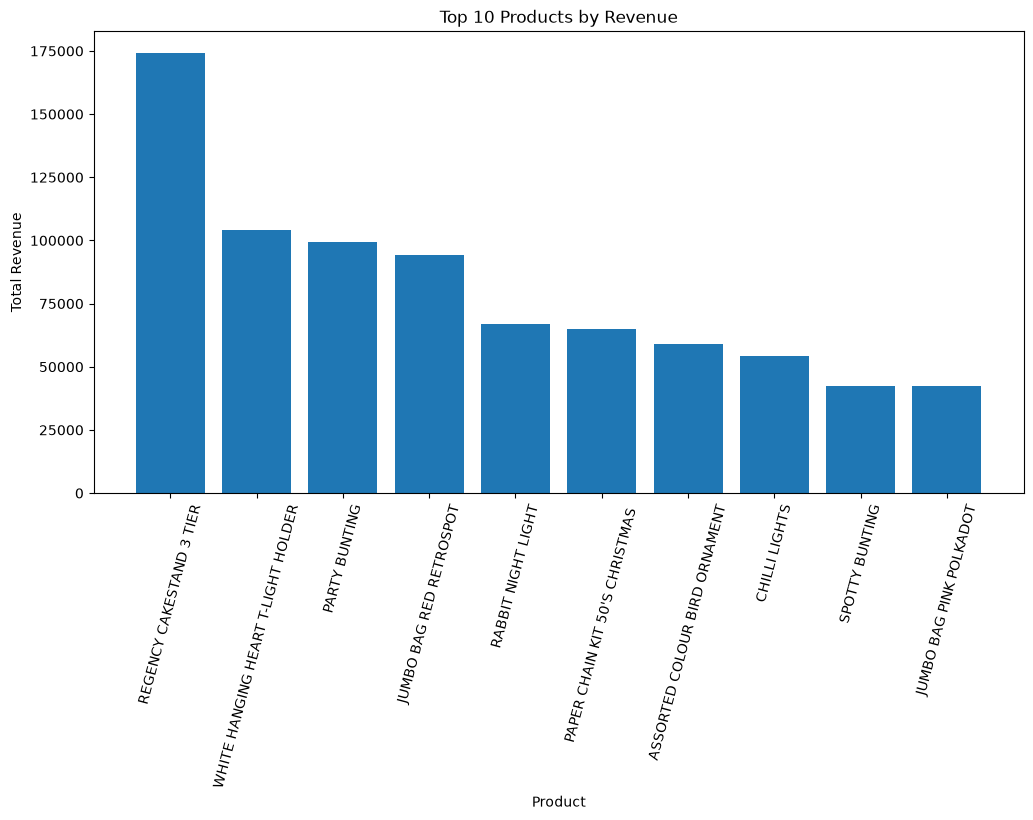

In [31]:
plt.figure(figsize=(12, 6))
plt.bar(top_products['Description'],top_products['TotalRevenue'])
plt.xticks(rotation=75)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')


### 11.3 Top 10 Countries by Revenue

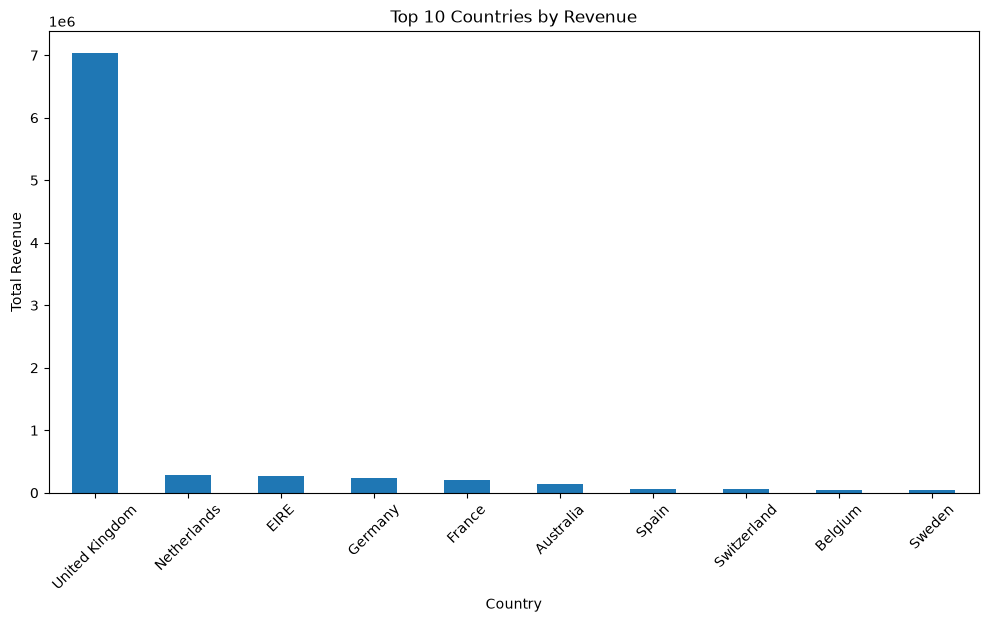

In [32]:
plt.figure(figsize=(12, 6))
country_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### 11.4 Revenue by Day of Week

This visualization shows the total revenue generated on each day of the week.

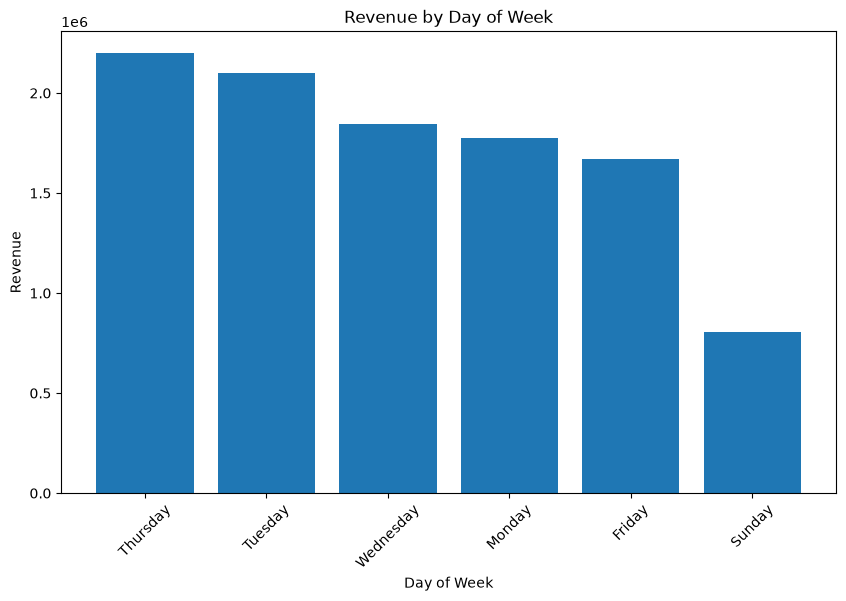

In [33]:
plt.figure(figsize=(10, 6))
plt.bar(weekday_sales.index, weekday_sales.values)

plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### 11.5 Revenue Distribution
This visualization shows the distribution of transaction revenue.
The analysis focuses on the main range of transaction values to make the distribution easier to interpret.

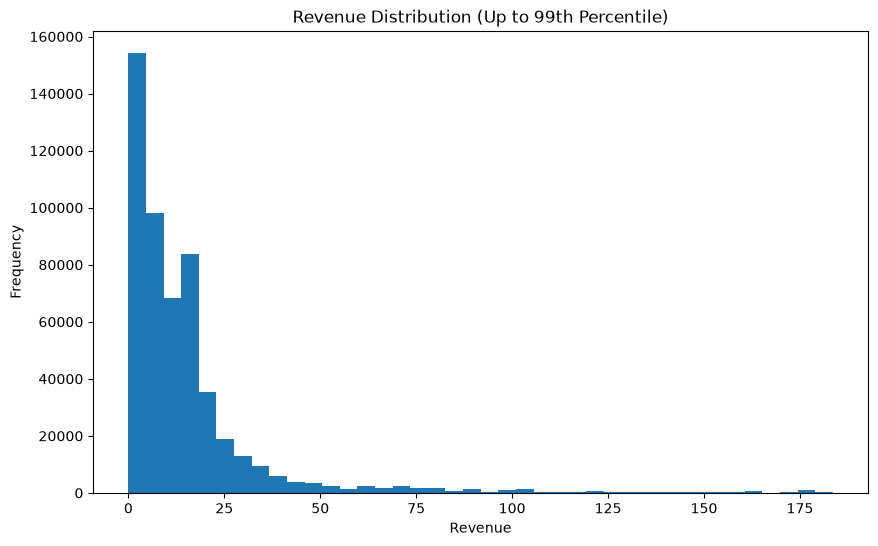

In [ ]:
plt.figure(figsize=(10, 6))
revenue_99 = np.percentile(sales_df_clean['Revenue'], 99)
plt.hist(sales_df_clean[sales_df_clean['Revenue'] <= revenue_99]['Revenue'],bins=40)
plt.title('Revenue Distribution (Up to 99th Percentile)')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

## 12. Business Insights

The analysis of the Online Retail dataset revealed several important business insights:

- November 2011 generated the highest monthly revenue and the highest number of orders.
- The United Kingdom was the dominant market and generated the largest share of total revenue.
- Some products generated high revenue because of a combination of strong sales volume and consistent demand.
- A relatively small group of customers generated a significant amount of revenue, highlighting the importance of customer retention.
- Revenue was concentrated during specific hours of the day, with the highest sales activity occurring around late morning and afternoon.
- Revenue distribution was strongly right-skewed, indicating that a small number of high-value transactions had a large impact on the overall revenue distribution.
- Some products had very low sales volume and revenue and may require further investigation regarding demand, seasonality, or product performance.

## 13. Conclusion

This project demonstrates how Python, Pandas, NumPy, and Matplotlib can be used to clean, analyze, visualize, and extract meaningful business insights from real-world retail transaction data.

The analysis covered sales performance, product performance, customer behavior, country-level sales, time-based patterns, and statistical characteristics of the dataset.

The results can help businesses better understand their customers, products, markets, and sales patterns and support data-driven decision making.